<img src="https://userweb.fct.unl.pt/~jmc.xavier/MSI/iLogos/nsst.jpg" width="400" height="100">

# DEMI | NOVA SST

## Mecânica dos Sólidos I

## Torção de barras elásticas
## Torção de barras elásticas. Parte I
## Problema 7 <a name="PV117"></a>

Uma barra de aço ($G = 70$ GPa) com 40 mm de diâmetro e 1,2 m de comprimento encaixa no interior de um tubo de latão ($G = 35$ GPa) com o mesmo comprimento. O tubo tem 40 mm de diâmetro interior e 50 de diâmetro exterior. O tubo e a barra estão fixos a flanges rígidas nos extremos A e B de forma a que se deformem em conjunto e a essas flanges é aplicado um momento torsor $T= 1000$ N.m.

[a)](#A) Calcule o ângulo de torção resultante.

[b)](#B) Represente a variação da tensão tangencial ao longo do raio e determine a tensão máxima em cada material.

<img src="https://userweb.fct.unl.pt/~jmc.xavier/MSI/Notebooks/Au11/Au11_P007_i1.jpg"
width="350" height="140">

## Resolução

#### a) Calcule o ângulo de torção resultante.<a name="A"></a> ([_enunciatum_](#PV117))

**Equilíbrio de momentos**

<img src="https://userweb.fct.unl.pt/~jmc.xavier/MSI/Notebooks/Au11/Au11_P007_i2.jpg"
width="320">

A análise do equilíbrio de momentos de torção na flange permite concluir que o momento torsor aplicado deve ser equilibrado por momentos de torção aplicados à secção da vida composta pelo aço e latão:

\begin{equation*}
T = T_\textrm{ac} + T_\textrm{la}
\end{equation*}

De onde se conclui que este problema é estaticamente indeterminado. Uma equação complementar pode ser incluida pela compatibilidade de ângulos de torção das regiões da secção composta.

**Compatibilidade de torção**

<img src="https://userweb.fct.unl.pt/~jmc.xavier/MSI/Notebooks/Au11/Au11_P007_i3.jpg"
width="350">

O ângulo de torção do veio composto deve satisfazer à seguinte equação  de compatibilidade:

\begin{equation*}
    \phi_{B/A} = \phi_\textrm{ac} = \phi_\textrm{la}
\end{equation*}

ou seja,

- $\phi_\textrm{ac}$ é o ângulo de torção do aço;
- $\phi_\textrm{la}$ é o ângulo de torção do latão.

Assimundo, $T, L, J, G$ constantes ao longo do veio composto, o ângulo de torção vem dado por:

\begin{equation*}
\phi_{B/A} = \frac{T L }{JG}
\end{equation*}

Desenvolvendo a equação de compatibilidade,

\begin{equation*}
\begin{aligned}
\phi_\textrm{ac} = \phi_\textrm{la}
&~\Leftrightarrow~\frac{T_\textrm{ac} L }{J_\textrm{ac}G_\textrm{ac}}
=\frac{T_\textrm{al} L }{J_\textrm{al}G_\textrm{al}}\\
&~\Leftrightarrow~\frac{2T_\textrm{ac} L }{ \pi r_\textrm{ac}^4 G_\textrm{ac}} =
\frac{2T_\textrm{al} L }{ \pi
\left( r_e^4-r_i^4 \right) G_\textrm{al}}
\end{aligned}
\end{equation*}

\begin{equation*}
\frac{T_\textrm{ac}}{T_\textrm{al}} =
\frac{r_\textrm{ac}^4}{ \left( r_e^4-r_i^4 \right)}
\frac{G_\textrm{ac}}{G_\textrm{al}}
= 1.39
\end{equation*}

Desta forma é possível obter um sistema de equações bem determinado:

\begin{equation*}
\begin{cases}
\displaystyle\frac{T_\textrm{ac}}{T_\textrm{al}} =~
\displaystyle\frac{r_A^4}{ \left( r_e^4-r_i^4 \right)}\frac{G_\textrm{ac}}{G_\textrm{al}}\\
T\quad =\quad T_\textrm{ac} + T_\textrm{al}
\end{cases}
\end{equation*}

In [1]:
import numpy as np
import sympy as sy
from sympy.solvers import solve
from sympy import symbols

# Dados
# ---------------------------------
# unidades: m, Pa, N
Ga,Gl = 70.e9, 35.e9
d, L, re = 0.040, 1.2, 0.050/2
ri = d/2
T = 1000. # unidade: N.m
# ---------------------------------

racioTaTl = ri**4*Ga/(re**4-ri**4)/Gl
print(f'racioTaTl = {racioTaTl:.4f}')

Ta, Tl = symbols('Ta, Tl')
sol1 = solve([Ta/Tl - racioTaTl, T - Ta - Tl],[Ta, Tl],dict=True)

Tan = sol1[0][Ta]
print(f'Tan = {Tan:.2f} N.m')
Tln = sol1[0][Tl]
print(f'Tln = {Tln:.2f} N.m')

racioTaTl = 1.3875
Tan = 581.16 N.m
Tln = 418.84 N.m


Conhecidas as frações de momento de torção transmitidos para o aço e o latão, o ângulo de torção pode ser determinado por:

\begin{equation*}
\phi \equiv \phi_A =
\frac{2T_\textrm{ac} L }{ \pi r_\textrm{ac}^4 G_\textrm{ac}}
\quad\vee\quad
\phi \equiv \phi_B =
\frac{2T_\textrm{al} L }{ \pi
\left( r_e^4-r_i^4 \right) G_\textrm{al}}
\end{equation*}

In [2]:
phi = float(2*Tan*L/np.pi/ri**4/Ga)
print(f'phi = {phi:.4f} rad | {np.rad2deg(phi):.2f} º')

phi = 0.0396 rad | 2.27 º


#### b) Represente a variação da tensão tangencial ao longo do raio e determine a tensão máxima em cada material.<a name="B"></a>([_enunciatum_](#P77))

A fórmula de torção relaciona a tensão de corte com o momento de torção pela relação:

\begin{equation*}
\tau = \frac{T \rho }{J}
\end{equation*}

_Aço :_

- $\rho \in [0, r_i]$: a tensão de corte deve ser calculada considerando o momento de torção no aço;

    \begin{equation*}
    \tau_\textrm{ac} = \frac{T_\textrm{ac} \rho }{J_\textrm{ac}} = 2.31\times 10^9 \rho
    \end{equation*}

    \begin{equation*}
    \tau_\textrm{ac}^\mathrm{max}|_{\rho = r_\textrm{ac}}
    = \frac{T_\textrm{ac} r_\textrm{ac}}{J_\textrm{ac}} = 46.25~\text{MPa}
    \end{equation*}

In [3]:
Ja = np.pi/2*ri**4
print(f'Ja = {Ja:.4e} (m^4)')
TaJa = Tan/Ja
print(f'TaJa = {TaJa:.4e} (N/m^3)')
tauAmax = TaJa*ri
print(f'tauAmax = {tauAmax*1e-6:.2f} (MPa)')

Ja = 2.5133e-07 (m^4)
TaJa = 2.3124e+9 (N/m^3)
tauAmax = 46.25 (MPa)


_Latão :_

- $\rho \in [r_i, r_e]$, a tensão de corte é dada em função do momento torsor aplicado no latão.

    \begin{equation*}
    \tau_\textrm{al} = \frac{T_\textrm{al} \rho }{J_\textrm{al}} = 1.16\times 10^9 \rho
    \end{equation*}

    \begin{equation*}
    \tau_\textrm{al}^\mathrm{min}|_{\rho = r_i} =
    \frac{T_\textrm{al} r_i }{J_\textrm{al}} = 23.12~\text{MPa}
    \end{equation*}

    \begin{equation*}
    \tau_\textrm{al}^\mathrm{max}|_{\rho = r_e}
    = \frac{T_\textrm{al} r_e }{J_\textrm{al}} = 28.90~\text{MPa}
    \end{equation*}

In [4]:
Jl = np.pi/2*(re**4-ri**4)
print(f'Jl = {Jl:.4e} m^4')
TlJl = Tln/Jl
print(f'TlJl = {TlJl:.4e} N/m^3')
tauLmin = TlJl*ri
print(f'tauLmin = {tauLmin*1e-6:.2f} MPa')
tauLmax = TlJl*re
print(f'tauLmax = {tauLmax*1e-6:.2f} MPa')

Jl = 3.6226e-07 m^4
TlJl = 1.1562e+9 N/m^3
tauLmin = 23.12 MPa
tauLmax = 28.90 MPa


**Variação da tensão tangencial ao longo do raio**

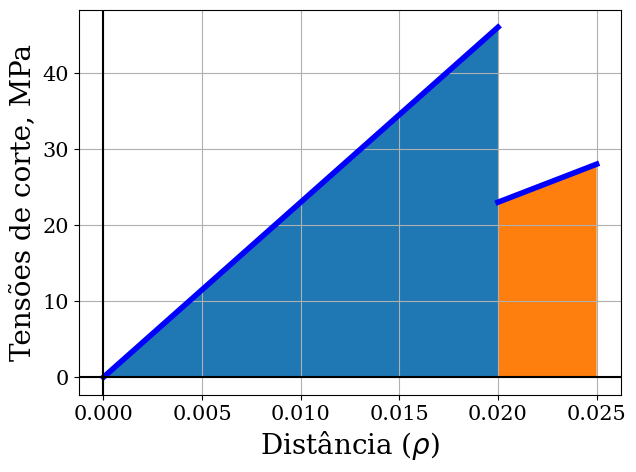

In [6]:
import matplotlib.pyplot as plt
size = 20
params = {'font.size': size,
    'axes.labelsize': size,
    'axes.titlesize': size,
    'xtick.labelsize': size*0.75,
    'ytick.labelsize': size*0.75}
plt.rcParams.update(params)

# use LaTeX fonts in the plot
plt.rc('text', usetex=False)
plt.rc('font', family='serif')

xp1 = np.linspace(0,ri)
yp1 = np.linspace(0,int(tauAmax*1e-6), endpoint=True,axis=0)

xp2 = np.linspace(ri,re,100)
yp2 = np.linspace(int(tauLmin*1e-6),int(tauLmax*1e-6),100)

plt.style.use('fast')

fig, ax = plt.subplots(figsize=(7,5))
# rho in [0,rhoC]
ax.plot(xp1, yp1, '-', linewidth=4, color='blue')
plt.fill_between(xp1,yp1)
ax.plot(xp2, yp2, '-', linewidth=4, color='blue')
plt.fill_between(xp2,yp2)
ax.set(xlabel=r'Distância ($\rho$)', ylabel='Tensões de corte, MPa')
ax.axhline(y=0, color='k')
ax.axvline(x=0, color='k')
ax.grid()
plt.show()

<img src="https://userweb.fct.unl.pt/~jmc.xavier/MSI/Notebooks/Au11/Au11_P007_i4.jpg"
width="500">

---

Copyright (c) [Mecânica dos Sólidos I - DEMI - NOVA-SST]

Interactive computing by <a href="https://jupyter.org/" target="_blank"> <span
style="color:#333399"> Jupyter Notebook </span> </a> &nbsp;|&nbsp;Coded by <a href = "mailto: jmc.xavier@fct.unl.pt">José Xavier</a>

Licensed under  <a href="http://creativecommons.org/licenses/by-sa/4.0/"
target="_blank"> <span style="color:#333399;font-size: 20px"> CC BY-SA 4.0  </span></a>
